# Functions

In [4]:
import pandas as pd
import numpy as np 
from pathlib import Path

DISTANCE_PATH = Path("../data/ArchiveII_distances.h5") 
SUBSAMPLED_PATH = Path("../results/ArchiveII_subsampled_ids.csv") 
figures_dir = Path("/home/gkulemeyer/Documents/DiskB/Guillermo/ImproveInterfam/figures")


families = [ "5s", "tRNA", "tmRNA", "RNaseP", "srp", "telom", "grp1", "23s", "16s"]
distances = pd.read_hdf(DISTANCE_PATH, key='rnadist')
distances /= distances.max().max()

df_ids = pd.read_csv(SUBSAMPLED_PATH)
df_ids["fam"] = df_ids["id"].str.split("_").str[0]
df_ids.loc[df_ids["fam"]=="telomerase", "fam"] = "telom"

In [5]:
splits = df_ids.partition.unique()
all_ids = {split: df_ids.query(f"partition == '{split}'")[["id","fam"]] for split in splits}  
ids = {}

for split in splits: 
    ids[split] = {}
    for fam in families:
        fam_ids = all_ids[split].query("fam == @fam")["id"].values
        ids[split][fam] = fam_ids

In [6]:
def add_marginals(df):
    df_ = df.copy()
    # add marginal column ( without diagonal)
    matrix = np.zeros_like(df.values)
    matrix[np.diag_indices_from(matrix)] = np.diag(df.values)
    df_ -= matrix
    col_marginal = df_.mean(axis=1)
    # add marginal row ( without diagonal)
    row_marginal = df_.mean(axis=0)
    df["marginal"] = col_marginal
    df.loc["marginal", :] = row_marginal
    df.loc["marginal", "marginal"] = 0
    return df

def get_tables(ids, distances, families, ref_strategy="full", train_to_test=False, marginals=False):
    # Compute the mean and min distance matrices for the current strategy
    strategies = {}
    deltas = {}
    for strategy, fam_dict in ids.items():
        strategies[strategy] = {}
        deltas[strategy] = {}
        
        # Extract the relevant submatrix of distances for the current family pair
        rows = []
        for fam1, id1_list in fam_dict.items():
            if train_to_test:
                compare_fam_dict = ids[ref_strategy]
            else:
                compare_fam_dict = fam_dict 

            for fam2, id2_list in compare_fam_dict.items():

                dist_mat = distances.loc[id1_list, id2_list] 
                mean = dist_mat.values.mean()
                min = dist_mat.values.min()
                rows.append({"fam1": fam1, "fam2": fam2, "mean": mean, "min": min})
                
        # Convert the list of rows into a table with the mean / min distance matrices
        for metric in ["mean", "min"]:
            strategies[strategy][metric] = (
                pd.DataFrame(rows)
                .pivot(index="fam1", columns="fam2", values=metric)
                .reindex(index=families, columns=families) 
                .rename_axis(index=None, columns=None)
                )  
            if marginals:
                strategies[strategy][metric] = add_marginals(strategies[strategy][metric])
            if strategy == ref_strategy:
                continue
            deltas[strategy][metric] = strategies[strategy][metric] - strategies[ref_strategy][metric]
    return strategies, deltas

In [7]:
ref_strategy = "full"
strategies, deltas = get_tables(ids, distances, families, ref_strategy=ref_strategy, train_to_test=True, marginals=True)

print(f"Strategies computed: {list(strategies.keys())}")
print(f"Metrics computed: {list(strategies[ref_strategy].keys())}")
display("Reference Strategy - Mean Distances", strategies[ref_strategy]["mean"])

Strategies computed: ['full', 'sortS400', 'sortS200', 'sortS100', 'clusS400', 'clusS200', 'clusS100', 'randS400', 'randS200', 'randS100']
Metrics computed: ['mean', 'min']


'Reference Strategy - Mean Distances'

,5s,tRNA,tmRNA,RNaseP,srp,telom,grp1,23s,16s,marginal
5s,0.115301,0.412489,0.574126,0.520952,0.517686,0.575956,0.568462,0.539540,0.530575,0.471087
tRNA,0.412489,0.085201,0.561786,0.561501,0.543039,0.629173,0.593165,0.542325,0.581040,0.491613
tmRNA,0.574126,0.561786,0.214500,0.488916,0.592600,0.533953,0.497321,0.544369,0.529318,0.480265
RNaseP,0.520952,0.561501,0.488916,0.332865,0.607323,0.559109,0.489872,0.527541,0.496990,0.472467
srp,0.517686,0.543039,0.592600,0.607323,0.413277,0.592366,0.608032,0.565944,0.556161,0.509239
telom,0.575956,0.629173,0.533953,0.559109,0.592366,0.200440,0.543382,0.546485,0.528748,0.501019
grp1,0.568462,0.593165,0.497321,0.489872,0.608032,0.543382,0.354821,0.517445,0.511801,0.481053
23s,0.539540,0.542325,0.544369,0.527541,0.565944,0.546485,0.517445,0.379837,0.525289,0.478771
16s,0.530575,0.581040,0.529318,0.496990,0.556161,0.528748,0.511801,0.525289,0.442673,0.473325
marginal,0.471087,0.491613,0.480265,0.472467,0.509239,0.501019,0.481053,0.478771,0.473325,0.000000


# Plots

In [8]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("white")

# Example Oxford Bioinformatics
#   simple column:  ~81.7 mm ≡ 3.22 in
#   double column: ~171.4 mm ≡ 6.75 in
sc = 3.22
dc = 6.75

fig_width1col = dc / 3 + 1
fig_height = dc / 3 + 1
font_size = 7

methods_width1col = 2 * dc / 3
methods_height = 2 * dc / 3
font_size = 7

save_path = Path("/home/gkulemeyer/Documents/DiskB/Guillermo/ImproveInterfam/figures")

Full strategy - Min Distances


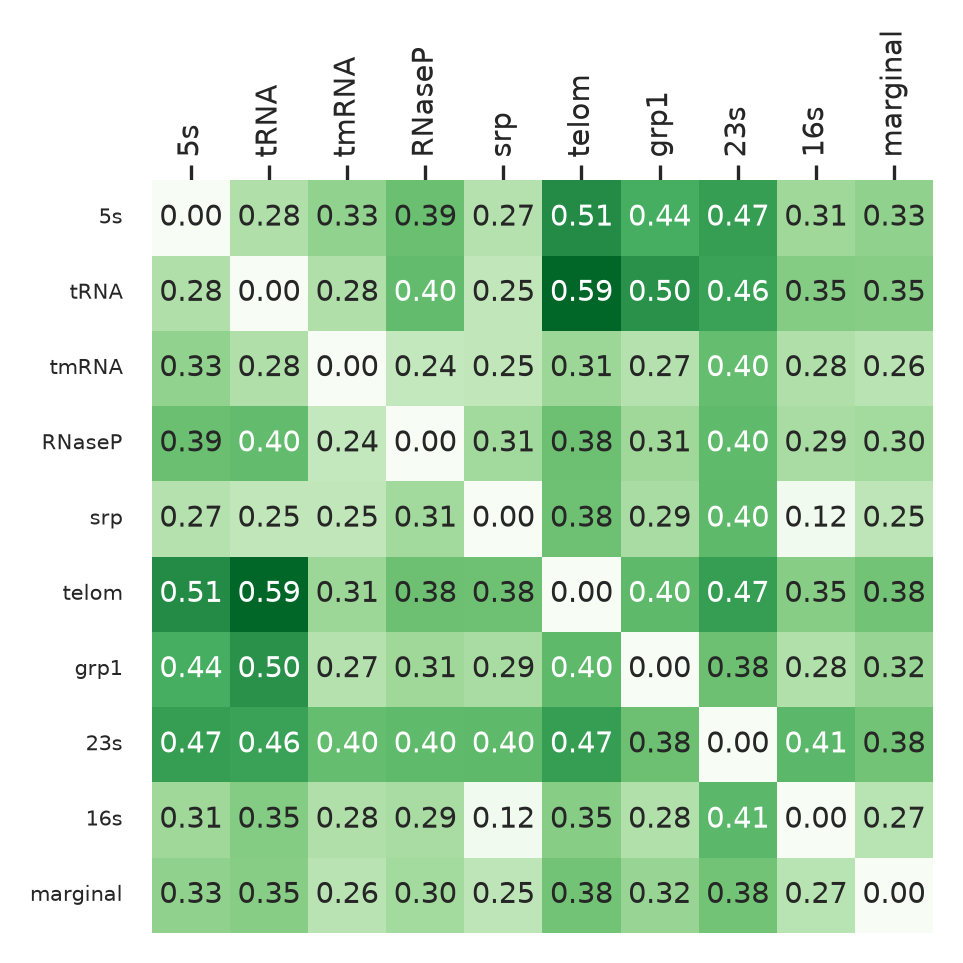

Full strategy - Mean Distances


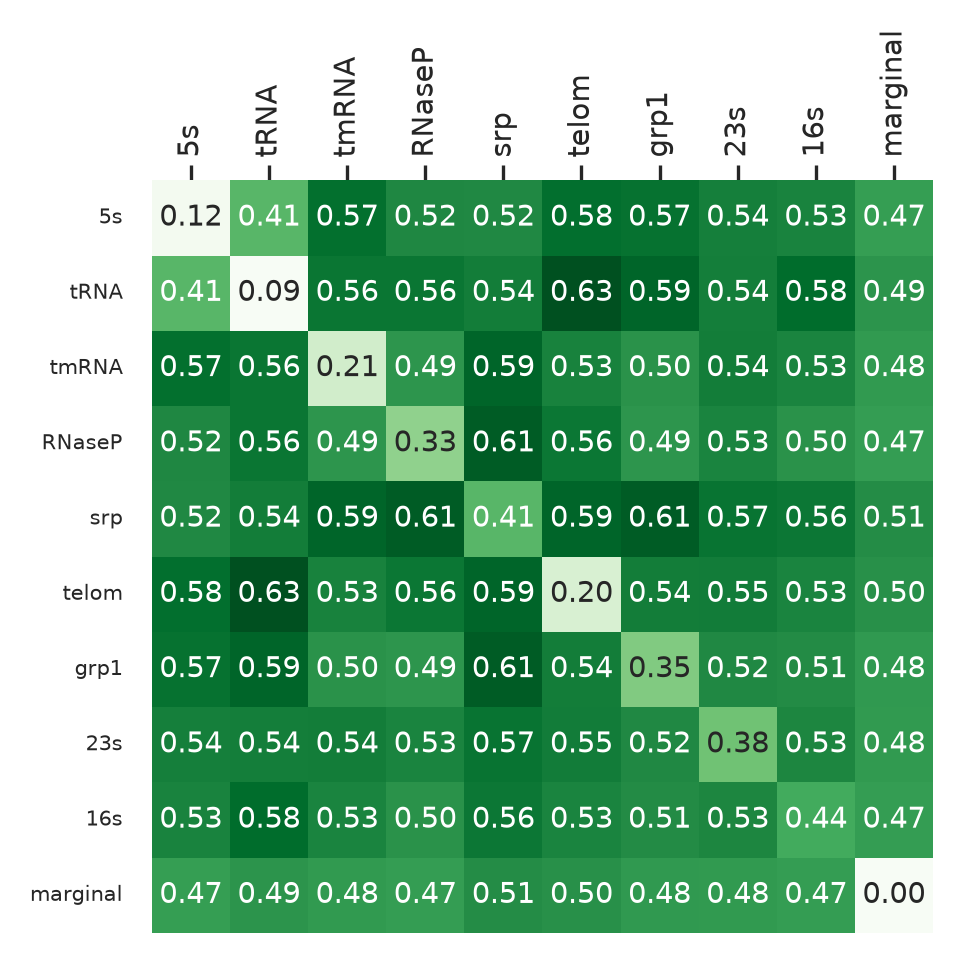

In [9]:
vmin = 0.1
vmax = 0.65
cmap = "Greens"

print("Full strategy - Min Distances")
### mins ###
plt.figure(figsize=(sc, sc), dpi=300)
plt.rcParams.update({'font.size': font_size})
plt.xticks(fontsize=font_size-2, rotation=45)
plt.yticks(fontsize=font_size-2)
# plot only the lower triangle of the matrix
sns.heatmap(strategies["full"]["min"], annot=True, cmap=cmap, fmt=".2f", cbar=False,  vmin=vmin, vmax=vmax)

ax = plt.gca()
ax.xaxis.tick_top()
ax.tick_params(
    axis="x",
    top=True,
    labeltop=True,
    bottom=False,
    labelbottom=False,
    labelsize=font_size,
    pad=2,
)
ax.set_xticklabels(strategies["full"]["min"].columns, rotation=90, fontsize=font_size)
plt.tight_layout() 
plt.savefig(save_path / "1C_min_ref.svg", dpi=300)
plt.show()

print("Full strategy - Mean Distances")
### means ###
plt.figure(figsize=(sc, sc), dpi=300)
plt.rcParams.update({'font.size': font_size})
plt.xticks(fontsize=font_size-2, rotation=45)
plt.yticks(fontsize=font_size-2)
sns.heatmap(strategies["full"]["mean"], annot=True, cmap=cmap, fmt=".2f", cbar=False,  vmin=vmin, vmax=vmax)

ax = plt.gca()
ax.xaxis.tick_top()
ax.tick_params(
    axis="x",
    top=True,
    labeltop=True,
    bottom=False,
    labelbottom=False,
    labelsize=font_size,
    pad=2,
)
ax.set_xticklabels(strategies["full"]["mean"].columns, rotation=90, fontsize=font_size)
plt.tight_layout() 
plt.savefig(save_path / "1D_mean_ref.svg", dpi=300)
plt.show()

# DELTA PLOTS

## Mins

In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
 
subsampled_families = ["5s", "tRNA", "tmRNA", "RNaseP", "srp", "marginal"]

sns.set_style("white")
DC = 6.75  # double column width in inches
FONT_SIZE = 7
FIG_WIDTH = 2 * DC / 3
FIG_HEIGHT = 2 * DC / 3

METHODS = ["randS", "sortS", "clusS"]
SIZES = ["400", "200", "100"]

VMIN = -0.1
VMAX = 0.1

# =============================================================================
# Helper functions
# =============================================================================

def make_cmap(n=256): 
    mid = n // 2
    blues = plt.cm.Blues_r(np.linspace(0.05, 1.0, mid))
    reds = plt.cm.Reds(np.linspace(0.05, 1.0, n - mid))
    colors = np.vstack([blues, reds])
    colors[mid - 1:mid + 1, :] = [1, 1, 1, 1]
    return mpl.colors.ListedColormap(colors)

def style_heatmap_axis(ax, row_idx, col_idx, method, size, table, font_size):

    n_rows, n_cols = table.shape
    # Ticks at the center of each heatmap cell
    ax.set_xticks(np.arange(n_cols) + 0.5)
    ax.set_yticks(np.arange(n_rows) + 0.5)

    # X labels: only top row
    if row_idx == 0:
        ax.xaxis.tick_top()
        ax.tick_params(
            axis="x",
            top=True,
            labeltop=True,
            bottom=False,
            labelbottom=False,
            labelsize=font_size,
            pad=2,
        )
        ax.set_xticklabels(table.columns, rotation=90, fontsize=font_size)
    else:
        ax.tick_params(axis="x", top=False, bottom=False, labeltop=False, labelbottom=False)
        ax.set_xticklabels([])

    # Y labels: only left column 
    if col_idx == 0:
        ax.tick_params(
            axis="y",
            left=True,
            labelleft=True,
            right=False,
            labelright=False,
            labelsize=font_size,
            pad=3,
        )
        ax.set_yticklabels(table.index, rotation=0, fontsize=font_size)
    else:
        ax.tick_params(axis="y", left=False, right=False, labelleft=False, labelright=False)
        ax.set_yticklabels([])

    # Method label: only right column
    if col_idx == 2:
        ax.text(
            1.08,
            0.5,
            method,
            transform=ax.transAxes,
            rotation=270,
            va="center",
            ha="left",
            fontsize=font_size + 2,
        )

    # Size label: only bottom row
    if row_idx == 2:
        ax.text(
            0.5,
            -0.12,
            size,
            transform=ax.transAxes,
            va="top",
            ha="center",
            fontsize=font_size + 2,
        )

    # Panel border
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.2)
        spine.set_edgecolor("0.7")

def plot_delta_heatmaps(
    deltas,
    metric="min",
    cmap=None,
    vmin=-0.1,
    vmax=0.1,
    figsize=(4.8, 4.8),
    font_size=6,
): 
    
    methods, sizes = ["randS", "sortS", "clusS"], ["400", "200", "100"]
    if cmap is None:
        cmap = make_cmap()

    plt.rcParams.update({"font.size": font_size})
    fig, axes = plt.subplots( 3, 3, figsize=figsize, dpi=300)

    for row_idx, method in enumerate(methods):
        for col_idx, size in enumerate(sizes):
            ax = axes[row_idx, col_idx]

            strategy = f"{method}{size}"
            table = deltas[strategy][metric].loc[subsampled_families, families]

            sns.heatmap(
                table,
                ax=ax,
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                cbar=False,
                annot=False,
                xticklabels=False,
                yticklabels=False,
            )

            style_heatmap_axis(
                ax=ax,
                row_idx=row_idx,
                col_idx=col_idx,
                method=method,
                size=size,
                table=table,
                font_size=font_size,
            )

    fig.subplots_adjust(
        left=0.22,
        right=0.88,
        top=0.82,
        bottom=0.16,
        wspace=0.08,
        hspace=0.08,
    )

    return fig, axes

Plotting delta mean heatmaps...


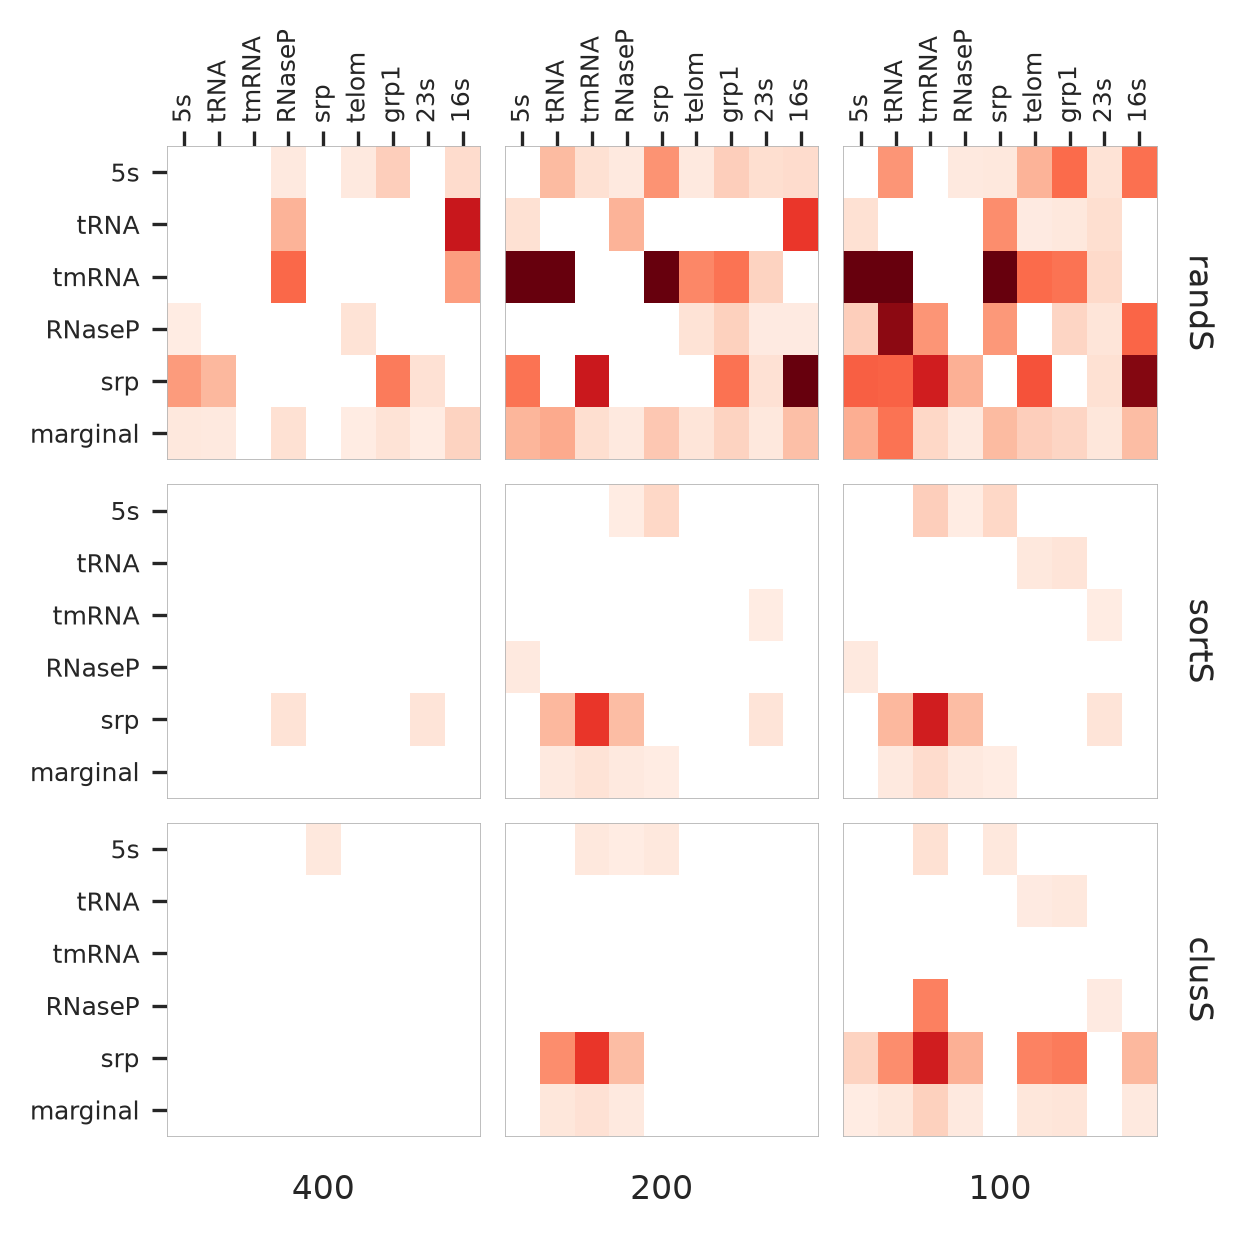

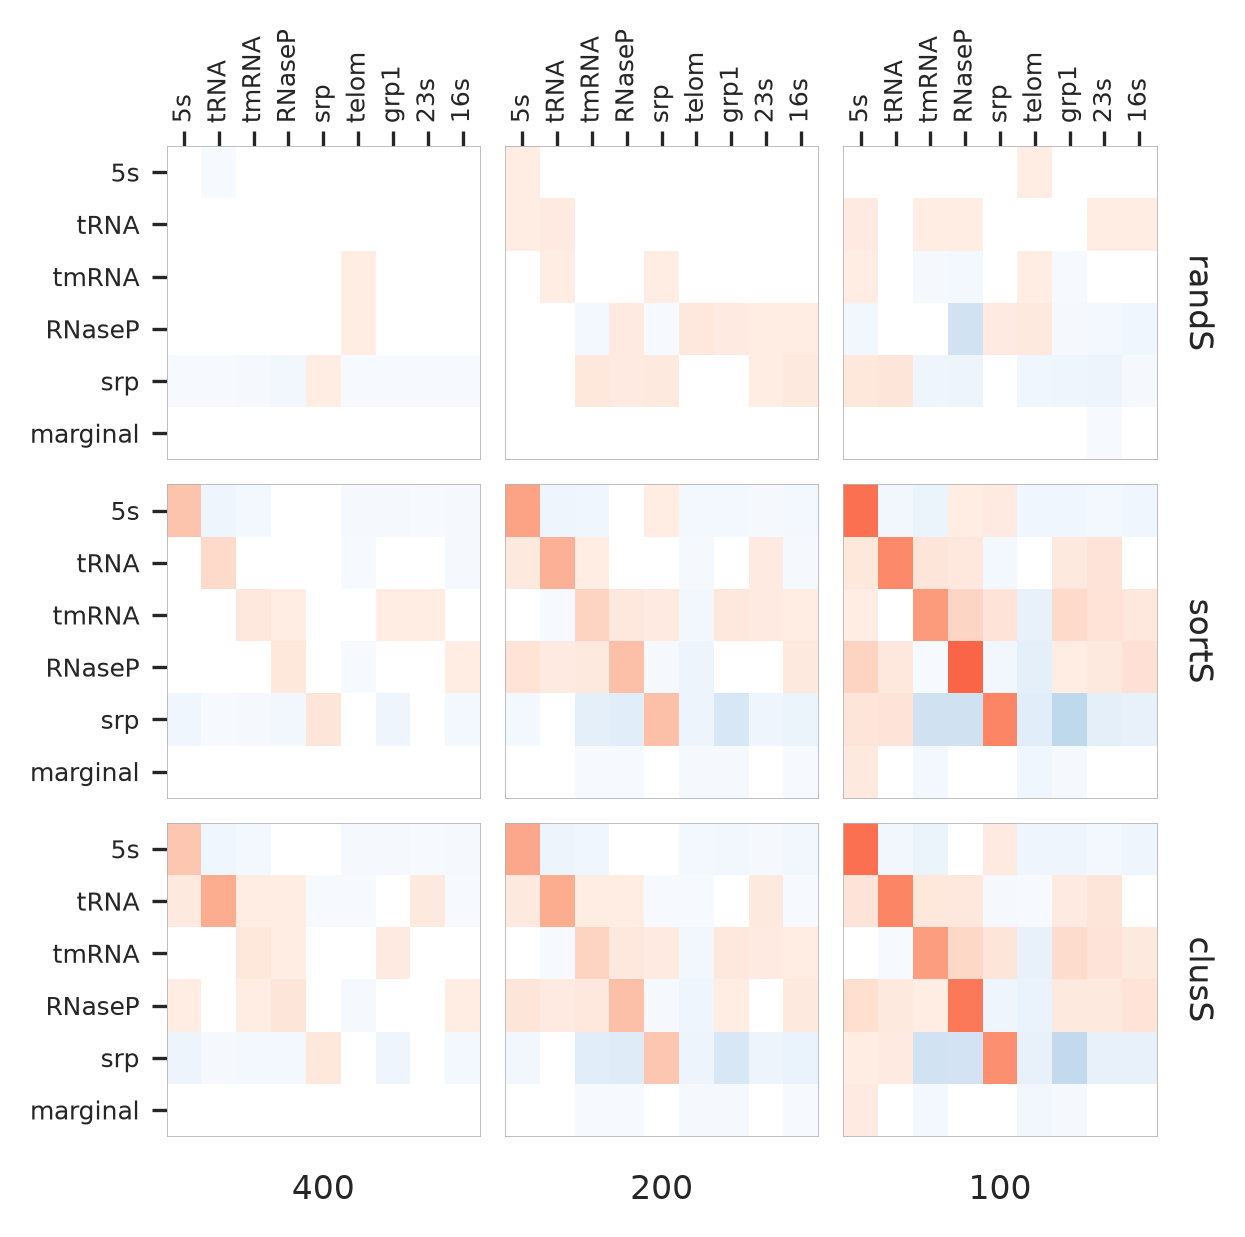

In [14]:
cmap = make_cmap()

print("Plotting delta mean heatmaps...")
fig, axes = plot_delta_heatmaps(
    deltas,
    metric="min",
    cmap=cmap,
    vmin=-0.1,
    vmax=0.1,
    figsize=(5.0, 5.0),
    font_size=6,
)

#SAVE 
fig.savefig(save_path / "1C_delta_min.svg", dpi=300)
plt.show()
 

fig, axes = plot_delta_heatmaps(
    deltas,
    metric="mean",
    cmap=cmap,
    vmax= 0.1, 
    vmin=-0.1,
    figsize=(5.0, 5.0),
    font_size=6,
)

fig.savefig(save_path / "1D_delta_mean.svg", dpi=300)
plt.show()